<a href="https://colab.research.google.com/github/raulmabcn/DataAnalyst/blob/main/Specialization/PythonVisualData/S1101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from dotenv import load_dotenv
import mysql.connector
import pandas as pd
from datetime import date

load_dotenv(dotenv_path=r'C:\\Users\\raulm\\Desktop\\DataAnalyst\\Specialization\\PythonVisualData\\.env')
MYSQL_PASSWORD = os.getenv('MYSQL_PASSWORD')


def connect_to_Mysql_database( config ):

  try:
    cns = mysql.connector.connect( **config )
  except mysql.connector.Error as err:
    if err.errno == mysql.connector.errorcode.ER_ACCESS_DENIED_ERROR:
      print("Error de autentificación")
    elif err.errno == mysql.connector.errorcode.ER_BAD_DB_ERROR:
      print("La base de datos no existe")
    raise
    
  return cns


def get_tables_from_database( connect ):

    cursor = connect.cursor()
    try:
        query = "SHOW TABLES"
        cursor.execute( query )

        tables = [table[0] for table in cursor.fetchall()]
        
    finally:
        cursor.close() 

    return tables


def get_data_from_database( connect, tables, chunk_size=50000 ):

    date_codes = (7, 10, 12)
    df_list = {}

    cursor = connect.cursor()

    try:
        for table in tables:

            query = f'SELECT * FROM {table}'
            cursor.execute( query )
            
            # cursor.description - ( [0]column_name, [1]type_code, [2]display_size, [3]internal_size, [4]precision, [5]sclase, [6]null_ok )
            description = cursor.description
            full_data   = []
            data_chunk  = cursor.fetchmany(chunk_size)
            
            while data_chunk:
                full_data.extend( data_chunk )
                data_chunk = cursor.fetchmany(chunk_size)

            # Opción de usar variables globales para guardas los dataframes. 
            # Así PowerBi los reconoce
            df_temp = pd.DataFrame( data=full_data, columns=[column[0] for column in description ] )
            for column in [column[0] for column in description if column[1] in date_codes]:
                df_temp[column] = pd.to_datetime(df_temp[column], errors='coerce')
            
            variable_name = 'df_'+ table
            globals()[variable_name] = df_temp
    
    finally:
        cursor.close()

    return None


def prepare_df_data():
    df_transaction['amount'] = pd.to_numeric( df_transaction['amount'], errors='coerce' )
    df_product['price']      = pd.to_numeric( df_product['price'], errors='coerce' )
    df_product['weight']     = pd.to_numeric( df_product['weight'], errors='coerce' )

    today = date.today()
    
    df_user['age'] = today.year - df_user['birth_date'].dt.year - ((df_user['birth_date'].dt.month > today.month) | \
                ((df_user['birth_date'].dt.month == today.month) & (df_user['birth_date'].dt.day > today.day))).astype(int)

    return None


config = {
    'user':     'root',
    'password':  MYSQL_PASSWORD,
    'host':     '127.0.0.1',
    'database': 'sprint4'
}

try:
    cns         = connect_to_Mysql_database( config )
    tables_db   = get_tables_from_database( cns )
    get_data_from_database( cns, tables_db )
    prepare_df_data()

# Genera un dataframe con la información del error para solventar la falta de transparencia de PowerBi
except Exception as e:
    error_msg = str(e)
    error_type = type(e).__name__
    df_resultado = pd.DataFrame({
        'Error Type': [error_type],
        'Error_message': [error_msg],
        'Status': ['FAIL']
    })
finally:
    if cns and cns.is_connected():
        cns.close()

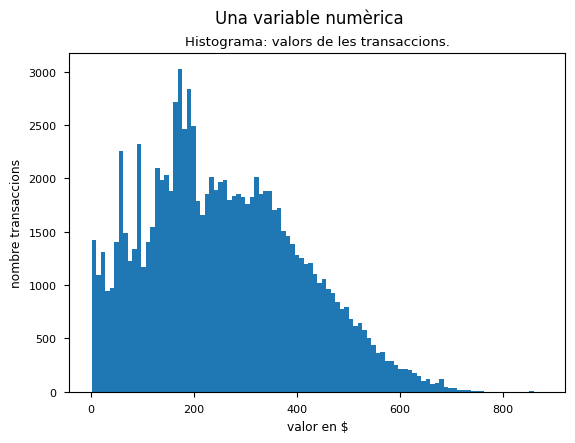

In [4]:
# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset = pd.DataFrame( df_transaction )

# --- End ---


import matplotlib.pyplot as plt


plt.style.use("seaborn-v0_8-paper")
plt.suptitle("Una variable numèrica")
plt.title( "Histograma: valors de les transaccions.")

plt.hist( dataset['amount'], bins=100 )

plt.ylabel('nombre transaccions')
plt.xlabel('valor en $')
plt.show()
plt.close()



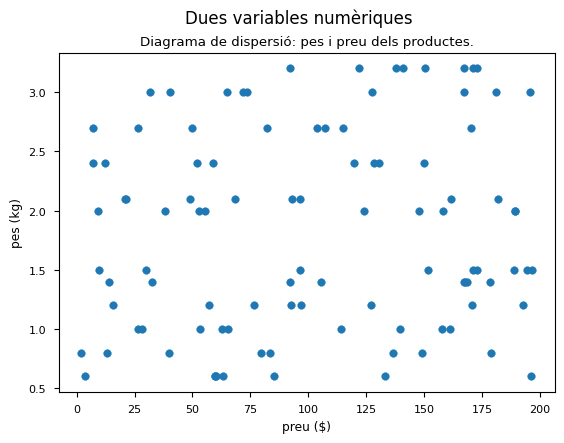

In [5]:

# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset = pd.DataFrame(df_product)

# --- End ---

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-paper")


plt.suptitle("Dues variables numèriques")
plt.title( "Diagrama de dispersió: pes i preu dels productes.")

plt.scatter( dataset['price'], dataset['weight'])


plt.xlabel('preu ($)')
plt.ylabel('pes (kg)')
plt.show()
plt.close()

In [ ]:
# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset = pd.DataFrame(df_company)

# --- End ---

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-paper")


plt.suptitle("Una variable categòrica")
plt.title( "Diagrama de barres: nombre companyies per pais.")

countries = dataset['country'].value_counts().sort_values(ascending=True)

plt.barh( y=countries.index, width=countries.values )

plt.ylabel('país')
plt.xlabel('nombre de companyies')
plt.show()
plt.close()

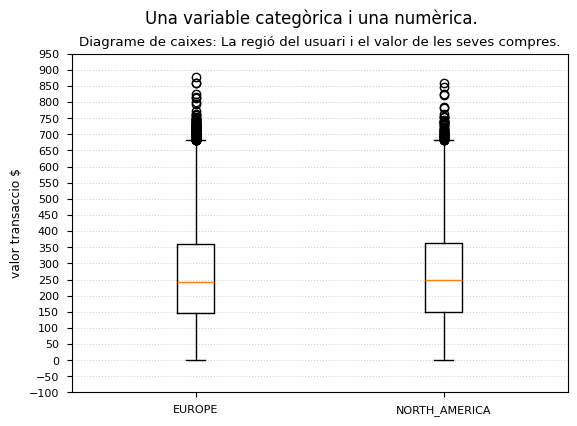

In [ ]:
# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset = pd.merge( df_user[['id','region']], df_transaction[['user_id','amount']], left_on='id', right_on='user_id', how='inner')

# --- End ---

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-paper")

regions = []
amounts = []

for region, group in dataset.groupby('region'):
    regions.append( region )            
    amounts.append( group['amount'] )

plt.suptitle( "Una variable categòrica i una numèrica." )
plt.title( "Diagrame de caixes: La regió del usuari i el valor de les seves compres.")

plt.boxplot( amounts, tick_labels=regions )

plt.ylabel("valor transaccio $")
plt.grid(visible=True, axis='y', color='lightgrey', linestyle=':')
plt.yticks(range(-100, 1000, 50)) 
plt.show()
plt.close()

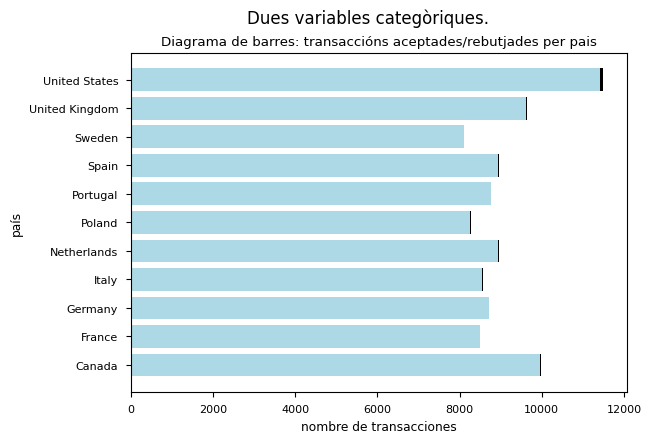

In [7]:
# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset = pd.merge(df_transaction[['id','user_id','declined']], df_user[['id','country']], left_on='user_id', right_on='id', how='inner'
                   ).rename( columns={'id_x':'id'} )

# --- End ---


import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-paper")

dataset = dataset.pivot_table( index='country', columns='declined', values='id', aggfunc='count')

plt.suptitle("Dues variables categòriques. ")
plt.title( "Diagrama de barres: transaccións aceptades/rebutjades per pais" )

plt.barh(dataset.index, dataset[0], color='lightblue', label='aceptades')
plt.barh(dataset.index, dataset[1], left=dataset[0],color='black', label='rebutjades')

plt.ylabel("país")
plt.xlabel("nombre de transacciones")
plt.show()
plt.close()

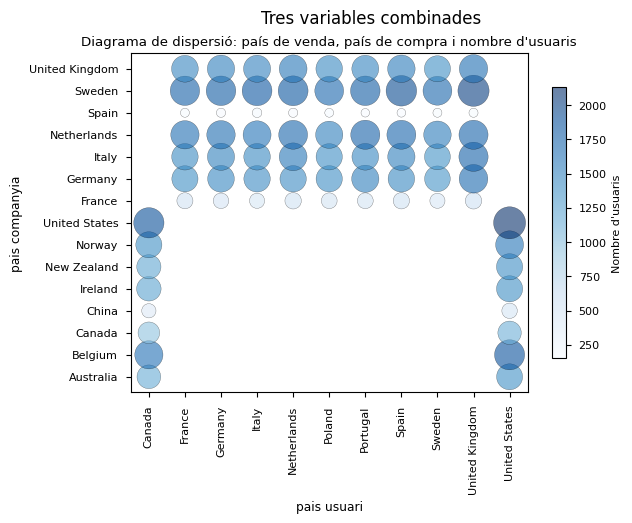

In [9]:
# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset    = pd.merge( df_company[['id','country']], df_transaction[['company_id','user_id']], left_on='id', right_on='company_id', how='inner' 
            ).rename( columns={'country' : 'country.1'}
            ).merge( df_user[['id','country']], left_on='user_id', right_on='id', how='inner'
            ).rename( columns={'country' : 'country'})

# --- End ---

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-paper")


dataset = dataset.rename(columns={'country':'user_country', 'country.1':'company_country'}
                         ).groupby(['user_country', 'company_country']).size().reset_index(name='num_users')


plt.suptitle("Tres variables combinades")
plt.title("Diagrama de dispersió: país de venda, país de compra i nombre d'usuaris")

sc = plt.scatter(
    dataset['user_country'],
    dataset['company_country'],
    s = dataset['num_users']*0.25,
    c = dataset['num_users'],
    cmap='Blues',
    alpha=0.6,
    edgecolors='black'
)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.05)
cbar.set_label("Nombre d'usuaris", fontsize=8)

plt.xlabel('pais usuari')
plt.ylabel('pais companyia')
plt.xticks(rotation=90)

plt.show()
plt.close()

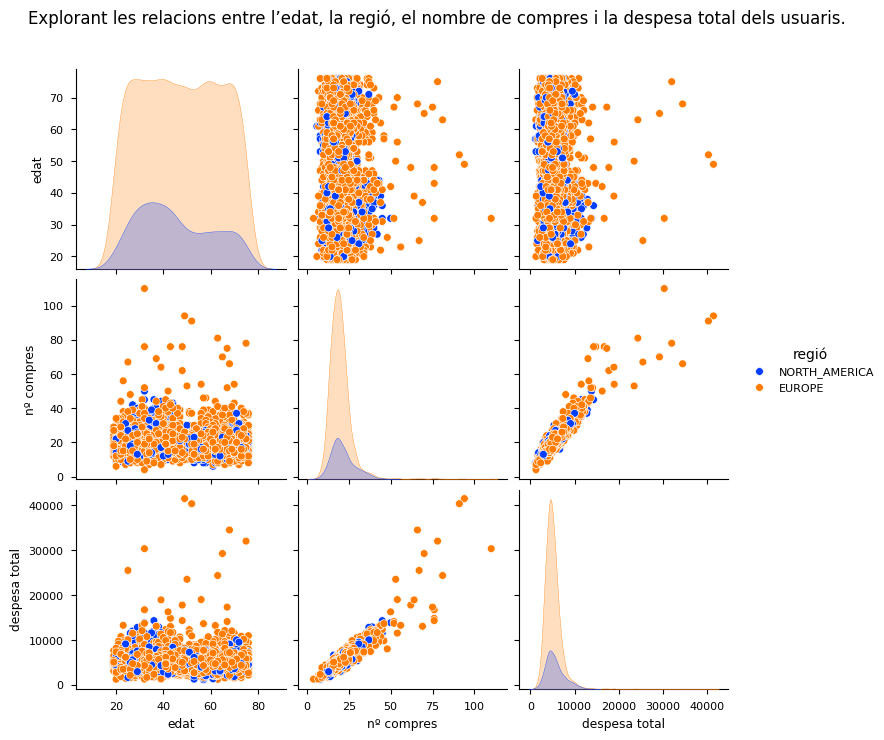

In [11]:


# El código entre estos comentarios es para que funcione en Jupyter
# No se usa en PowerBi
# --- Begin ---
dataset = pd.merge(
    df_user[['id', 'age', 'region']], 
    df_transaction[['id', 'user_id', 'amount']], 
    left_on='id', right_on='user_id', how='inner'
)
dataset = dataset.rename(columns={'id_y': 'transaction_id'}).drop(columns=['id_x'])

# --- End ---

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-paper")


df_ut = dataset.groupby(['user_id', 'age', 'region']).agg(
    total_purchases=('transaction_id', 'size'),
    total_amount=('amount', 'sum')
).reset_index()

df_ut           = df_ut[['age', 'total_purchases', 'total_amount', 'region']].dropna()
df_ut.columns   = ['edat', 'nº compres', 'despesa total','regió']

pair = sns.pairplot(
    df_ut, 
    hue='regió', 
    palette='bright'
)

pair.figure.suptitle("Explorant les relacions entre l’edat, la regió, el nombre de compres i la despesa total dels usuaris.")
pair.figure.subplots_adjust(top=0.90)

plt.show()
plt.close()
